# Advanced MLP PyTorch Retraining

This notebook trains the PyTorch MLP on the new advanced feature dataset, tunes it with Optuna, and logs to a new MLflow experiment.

In [20]:
import logging
import warnings
from typing import Dict, Any, List, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)
import optuna
import mlflow
import mlflow.pytorch

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')
logger = logging.getLogger(__name__)

# Constants
RANDOM_STATE = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.15
BATCH_SIZE = 256
N_EPOCHS = 300
PATIENCE = 20
LR = 1e-3
WEIGHT_DECAY = 1e-4
TARGET_COL = 'Churn'
PATH_DATA = '../notebooks/data/processed/churn_processed_advanced.csv'
EXPERIMENT = '03_PyTorch_Advanced_FE'

mlflow_tracking_uri = "http://127.0.0.1:5000"
mlflow.set_tracking_uri(mlflow_tracking_uri)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')


In [21]:
# Load Data and Split
df = pd.read_csv(PATH_DATA)

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_train
)

logger.info(f"Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)}")

n_pos = int(y_tr.sum())
n_neg = len(y_tr) - n_pos
POS_WEIGHT = n_neg / n_pos
logger.info(f"pos_weight: {POS_WEIGHT:.4f}")


In [22]:
# MLP Architecture
class ChurnMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout_rate: float = 0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout_rate),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)

def train_mlp(model, X_tr_np, y_tr_np, X_val_np, y_val_np, pos_weight,
              n_epochs=N_EPOCHS, batch_size=BATCH_SIZE, lr=LR,
              patience=PATIENCE, weight_decay=WEIGHT_DECAY):
    X_tr_t = torch.FloatTensor(X_tr_np).to(device)
    y_tr_t = torch.FloatTensor(y_tr_np).to(device)
    X_val_t = torch.FloatTensor(X_val_np).to(device)
    y_val_t = torch.FloatTensor(y_val_np).to(device)

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_STATE),
    )

    pw = torch.tensor([pos_weight], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_pr_auc = -np.inf
    best_state = {}
    patience_cnt = 0
    history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_probs = torch.sigmoid(val_logits).cpu().numpy()

        val_pr_auc = average_precision_score(y_val_np, val_probs)
        history.append({'epoch': epoch, 'val_pr_auc': val_pr_auc})

        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1

        if patience_cnt >= patience:
            break

    model.load_state_dict(best_state)
    return model, history

def compute_metrics(name: str, y_true: np.ndarray, y_scores: np.ndarray, threshold: float = 0.5) -> Dict[str, Any]:
    y_pred = (y_scores >= threshold).astype(int)
    return {
        'model': name,
        'roc_auc': round(roc_auc_score(y_true, y_scores), 4),
        'pr_auc': round(average_precision_score(y_true, y_scores), 4),
        'f1': round(f1_score(y_true, y_pred, zero_division=0), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
    }

def mlp_predict_proba(model: nn.Module, X_np: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        logits = model(torch.FloatTensor(X_np).to(device))
        return torch.sigmoid(logits).cpu().numpy()


In [23]:
# Train Vanilla Advanced MLP (Baseline)
INPUT_DIM = X_tr.shape[1]
HIDDEN_DIMS_BASE = [128, 64]
DROPOUT_RATE_BASE = 0.3

mlp_base = ChurnMLP(INPUT_DIM, HIDDEN_DIMS_BASE, DROPOUT_RATE_BASE).to(device)

logger.info('Training MLP Baseline...')
mlp_base, history_base = train_mlp(
    model=mlp_base,
    X_tr_np=X_tr.values,
    y_tr_np=y_tr.values.astype(np.float32),
    X_val_np=X_val.values,
    y_val_np=y_val.values.astype(np.float32),
    pos_weight=1.0, # Baseline sem class weight
)

mlp_base_scores = mlp_predict_proba(mlp_base, X_test.values)
base_metrics = compute_metrics('mlp_advanced_baseline', y_test.values, mlp_base_scores)
logger.info(f"Baseline PR-AUC: {base_metrics['pr_auc']:.4f}")

mlflow.set_experiment(EXPERIMENT)
with mlflow.start_run(run_name='mlp_advanced_baseline'):
    mlflow.log_params({'model': 'mlp_advanced_baseline', 'input_dim': INPUT_DIM})
    for k, v in base_metrics.items():
        if k != 'model':
            mlflow.log_metric(k, float(v))
    mlflow.pytorch.log_model(mlp_base, artifact_path='model', registered_model_name='MLP_Baseline_Advanced')


2026/04/23 13:23:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 13:23:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Registered model 'MLP_Baseline_Advanced' already exists. Creating a new version of this model...
2026/04/23 13:23:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MLP_Baseline_Advanced, version 2


🏃 View run mlp_advanced_baseline at: http://127.0.0.1:5000/#/experiments/3/runs/d141287246c944a5a87672229b7eb894
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '2' of model 'MLP_Baseline_Advanced'.


In [24]:
# Optuna Tuning for Advanced MLP
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    hidden_size_1 = trial.suggest_categorical("hidden_size_1", [32, 64, 128])
    hidden_size_2 = trial.suggest_categorical("hidden_size_2", [16, 32, 64])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    use_class_weights = trial.suggest_categorical("use_class_weights", [True, False])

    hidden_dims = [hidden_size_1, hidden_size_2]
    model = ChurnMLP(INPUT_DIM, hidden_dims, dropout_rate).to(device)
    pos_w = POS_WEIGHT if use_class_weights else 1.0

    model, history = train_mlp(
        model=model,
        X_tr_np=X_tr.values,
        y_tr_np=y_tr.values.astype(np.float32),
        X_val_np=X_val.values,
        y_val_np=y_val.values.astype(np.float32),
        pos_weight=pos_w,
        lr=lr,
        weight_decay=weight_decay
    )

    hist_df = pd.DataFrame(history)
    return hist_df['val_pr_auc'].max()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize", study_name="MLP_Advanced_Tuning")
study.optimize(objective, n_trials=30)

logger.info(f"Best Trial PR-AUC: {study.best_value:.4f}")

best_params = study.best_params
best_hidden_dims = [best_params["hidden_size_1"], best_params["hidden_size_2"]]

mlp_tuned = ChurnMLP(INPUT_DIM, best_hidden_dims, best_params["dropout_rate"]).to(device)
best_pos_w = POS_WEIGHT if best_params["use_class_weights"] else 1.0

mlp_tuned, history_tuned = train_mlp(
    model=mlp_tuned,
    X_tr_np=X_tr.values,
    y_tr_np=y_tr.values.astype(np.float32),
    X_val_np=X_val.values,
    y_val_np=y_val.values.astype(np.float32),
    pos_weight=best_pos_w,
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

mlp_tuned_scores = mlp_predict_proba(mlp_tuned, X_test.values)
tuned_metrics = compute_metrics('mlp_advanced_tuned', y_test.values, mlp_tuned_scores)

with mlflow.start_run(run_name='mlp_advanced_tuned'):
    mlflow.log_params(best_params)
    for k, v in tuned_metrics.items():
        if k != 'model':
            mlflow.log_metric(k, float(v))
    mlflow.pytorch.log_model(mlp_tuned, artifact_path='model', registered_model_name='MLP_Tuned_Advanced')


2026/04/23 13:24:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 13:24:03 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Registered model 'MLP_Tuned_Advanced' already exists. Creating a new version of this model...
2026/04/23 13:24:05 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: MLP_Tuned_Advanced, version 2


🏃 View run mlp_advanced_tuned at: http://127.0.0.1:5000/#/experiments/3/runs/58d09799deaa4c0c8ad6f527b7058a04
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '2' of model 'MLP_Tuned_Advanced'.


In [25]:
# Comparison
comparison_df = pd.DataFrame([base_metrics, tuned_metrics]).set_index('model')
display(comparison_df)


,roc_auc,pr_auc,f1,precision,recall
model,,,,,
mlp_advanced_baseline,0.8439,0.6476,0.6141,0.6243,0.6043
mlp_advanced_tuned,0.8449,0.6487,0.6152,0.4920,0.8209


2026/04/23 13:24:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 13:24:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'LogisticRegression_Advanced' already exists. Creating a new version of this model...
2026/04/23 13:24:06 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LogisticRegression_Advanced, version 2


🏃 View run logistic_regression_baseline at: http://127.0.0.1:5000/#/experiments/3/runs/e6ad88ed24634df9a764c4867269a666
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Created version '2' of model 'LogisticRegression_Advanced'.


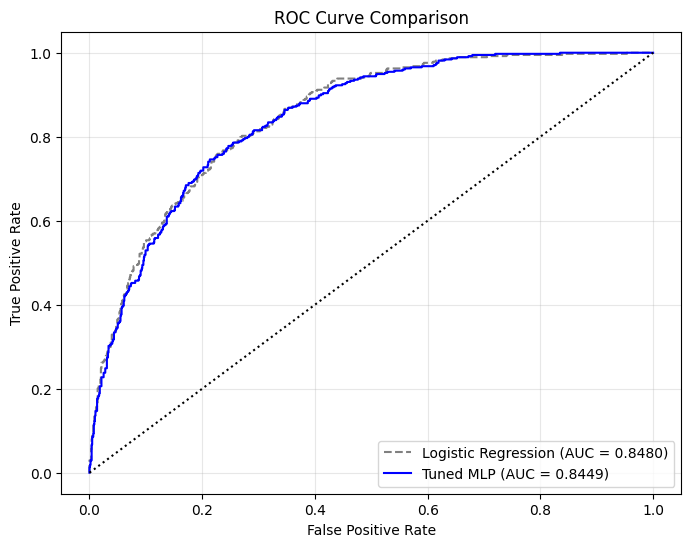

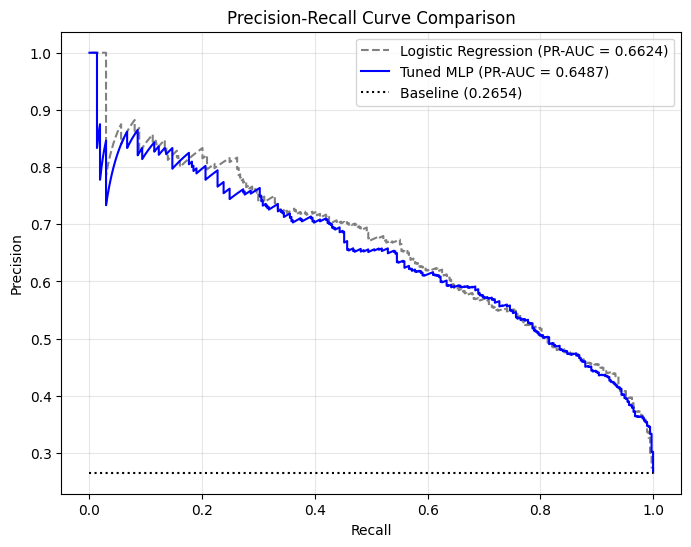

In [26]:
# Logistic Regression Baseline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, precision_recall_curve, auc

logger.info('Training Logistic Regression Baseline...')
lr_model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_tr.values, y_tr.values)

lr_scores = lr_model.predict_proba(X_test.values)[:, 1]
lr_metrics = compute_metrics('logistic_regression', y_test.values, lr_scores)
logger.info(f"LR PR-AUC: {lr_metrics['pr_auc']:.4f}")

# Plots
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
fig_pr, ax_pr = plt.subplots(figsize=(8, 6))

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test.values, lr_scores)
ax_roc.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_metrics['roc_auc']:.4f})", color='gray', linestyle='--')

fpr_mlp, tpr_mlp, _ = roc_curve(y_test.values, mlp_tuned_scores)
ax_roc.plot(fpr_mlp, tpr_mlp, label=f"Tuned MLP (AUC = {tuned_metrics['roc_auc']:.4f})", color='blue')

ax_roc.plot([0, 1], [0, 1], color='black', linestyle=':')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.3)

# PR
prec_lr, rec_lr, _ = precision_recall_curve(y_test.values, lr_scores)
ax_pr.plot(rec_lr, prec_lr, label=f"Logistic Regression (PR-AUC = {lr_metrics['pr_auc']:.4f})", color='gray', linestyle='--')

prec_mlp, rec_mlp, _ = precision_recall_curve(y_test.values, mlp_tuned_scores)
ax_pr.plot(rec_mlp, prec_mlp, label=f"Tuned MLP (PR-AUC = {tuned_metrics['pr_auc']:.4f})", color='blue')

baseline_pr = y_test.values.sum() / len(y_test.values)
ax_pr.plot([0, 1], [baseline_pr, baseline_pr], color='black', linestyle=':', label=f'Baseline ({baseline_pr:.4f})')
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curve Comparison')
ax_pr.legend(loc='upper right')
ax_pr.grid(True, alpha=0.3)

# Append plots to a new MLflow run for the logistic regression
mlflow.set_experiment(EXPERIMENT)
with mlflow.start_run(run_name='logistic_regression_baseline'):
    mlflow.log_params({'model': 'logistic_regression'})
    for k, v in lr_metrics.items():
        if k != 'model':
            mlflow.log_metric(k, float(v))
    mlflow.sklearn.log_model(lr_model, artifact_path='model', registered_model_name='LogisticRegression_Advanced')
    mlflow.log_figure(fig_roc, "comparison_roc_curve.png")
    mlflow.log_figure(fig_pr, "comparison_pr_curve.png")
    logger.info("Logged LR baseline and comparison figures to MLflow.")
